In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import numpy as np
import pandas as pd
import os
import nibabel as nib
import random
from collections import defaultdict
import time
import matplotlib.pyplot as plt
from torch.nn.utils import spectral_norm
import glob


# Kiểm tra GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Thiết bị đang sử dụng: {device}")

# Giải phóng VRAM
torch.cuda.empty_cache()

# Kiểm tra dung lượng ổ đĩa
def check_disk_space():
    stat = os.statvfs('/kaggle/working/')
    free_space = stat.f_bavail * stat.f_frsize / 1024**3
    print(f"Dung lượng trống: {free_space:.2f}GB")
    return free_space

check_disk_space()
if check_disk_space() < 1:
    print("Cảnh báo: Dung lượng ổ đĩa thấp, xóa file cũ...")
    for f in glob.glob("/kaggle/working/*.pth"):
        os.remove(f)
    for f in glob.glob("/kaggle/working/*.png"):
        os.remove(f)

# Xử lý participants.xlsx: Xóa hai subject không mong muốn
participants_file_input = "/kaggle/input/processed-mri-slices/participants.xlsx"
participants_file_output = "/kaggle/working/processed_mri_slices/participants.xlsx"

# Đọc file gốc
participants_df = pd.read_excel(participants_file_input)

# Xóa hai subject không mong muốn
subjects_to_remove = ['sub-BrainAge019983', 'sub-BrainAge005600']
participants_df = participants_df[~participants_df['subject_id'].isin(subjects_to_remove)]

# Tạo thư mục đích nếu chưa tồn tại
os.makedirs(os.path.dirname(participants_file_output), exist_ok=True)

# Lưu file đã chỉnh sửa
participants_df.to_excel(participants_file_output, index=False)
print(f"Đã xóa {len(subjects_to_remove)} subject và lưu file participants.xlsx tại {participants_file_output}")

# Đọc thông tin subject từ participants.xlsx đã chỉnh sửa
subject_info = {}
for _, row in participants_df.iterrows():
    subject_id = row['subject_id']
    subject_info[subject_id] = {
        'age': float(row['subject_age']),
        'gender': 1 if row['subject_sex'] == 'm' else 0
    }

# Tạo chỉ mục cho truy vấn real_B, giới hạn tuổi 20-80
data_dir = "/kaggle/input/processed-mri-slices"
subjects = [s for s in os.listdir(data_dir) if s.startswith('sub-BrainAge')]
ages = [subject_info[s]['age'] for s in subjects]
genders = [subject_info[s]['gender'] for s in subjects]
min_age = 20
max_age = 80
ages_normalized = (np.array(ages) - min_age) / (max_age - min_age)
condition_cache = defaultdict(list)
for idx, subject_id in enumerate(subjects):
    age = int(ages[idx])
    if min_age <= age <= max_age:
        gender = genders[idx]
        condition_cache[(age, gender)].append(idx)

# Kiểm tra ảnh gốc
def check_original_mri(data_dir, subjects):
    subject_id = subjects[0]
    subject_dir = os.path.join(data_dir, subject_id, "anat")
    file_path = os.path.join(subject_dir, f"{subject_id}_T1w_axial.nii")
    mri_img = nib.load(file_path)
    mri_data = mri_img.get_fdata()
    if mri_data.ndim == 3 and mri_data.shape[0] == 1:
        mri_data = mri_data[0]
    elif mri_data.ndim == 3 and mri_data.shape[0] > 1:
        mri_data = mri_data[0]
    plt.figure()
    plt.imshow(mri_data, cmap='gray')
    plt.title(f"Original MRI Axial ({subject_id})")
    plt.axis('off')
    plt.show()
    print("Đã hiển thị ảnh gốc")
    
# Dataset với preload
class MRIDataset(Dataset):
    def __init__(self, data_dir, subjects, subject_info, target_shape=(128, 128)):
        self.data_dir = data_dir
        self.subjects = subjects
        self.subject_info = subject_info
        self.target_shape = target_shape
        self.data = []
        
        print("Preloading dataset...")
        for subject_id in subjects:
            subject_dir = os.path.join(data_dir, subject_id, "anat")
            slices = []
            for slice_type in ['axial', 'coronal', 'sagittal']:
                file_path = os.path.join(subject_dir, f"{subject_id}_T1w_{slice_type}.nii")
                mri_img = nib.load(file_path)
                mri_data = mri_img.get_fdata()
                if mri_data.ndim == 3 and mri_data.shape[0] == 1:
                    mri_data = mri_data[0]
                elif mri_data.ndim == 3 and mri_data.shape[0] > 1:
                    mri_data = mri_data[0]
                if np.any(np.isnan(mri_data)) or np.any(np.isinf(mri_data)):
                    print(f"Cảnh báo: MRI {file_path} chứa nan/inf")
                    mri_data = np.nan_to_num(mri_data, nan=0.0, posinf=1.0, neginf=-1.0)
                mri_normalized = (mri_data - mri_data.min()) / (mri_data.max() - mri_data.min() + 1e-8)
                mri_normalized = mri_normalized * 2 - 1
                slices.append(mri_normalized)
            mri_tensor = torch.tensor(np.stack(slices), dtype=torch.float32)
            age = (subject_info[subject_id]['age'] - min_age) / (max_age - min_age) if min_age <= subject_info[subject_id]['age'] <= max_age else 0
            gender = subject_info[subject_id]['gender']
            condition = torch.tensor([age, gender], dtype=torch.float32)
            self.data.append((mri_tensor, condition))
        print("Dataset preloaded.")
    
    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, idx):
        return self.data[idx]

# Hàm truy vấn ảnh
def get_image_and_condition(idx, dataset):
    mri_tensor, condition = dataset[idx]
    return mri_tensor.to(device), condition.to(device)

# Tạo Dataset và DataLoader
dataset = MRIDataset(data_dir, subjects, subject_info, target_shape=(128, 128))
dataloader = DataLoader(dataset, batch_size=8, shuffle=True, num_workers=0, pin_memory=True)


Thiết bị đang sử dụng: cuda
Dung lượng trống: 19.50GB
Dung lượng trống: 19.50GB
Đã xóa 2 subject và lưu file participants.xlsx tại /kaggle/working/processed_mri_slices/participants.xlsx
Preloading dataset...
Dataset preloaded.


In [2]:
# Generator với Unet và skip connections
class Generator(nn.Module):
    def __init__(self, condition_dim=4, in_channels=3):
        super(Generator, self).__init__()
        self.condition_dim = condition_dim
        self.condition_layer = nn.Sequential(
            nn.Linear(condition_dim, 128),
            nn.ReLU(),
        )

        # Encoder
        self.enc1 = nn.Conv2d(in_channels + 1, 64, kernel_size=4, stride=2, padding=1)
        self.enc2 = nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1)
        self.enc3 = nn.Conv2d(128, 256, kernel_size=4, stride=2, padding=1)
        self.enc4 = nn.Conv2d(256, 512, kernel_size=4, stride=2, padding=1)

        # Decoder với skip connections
        self.dec4 = nn.ConvTranspose2d(512, 256, kernel_size=4, stride=2, padding=1)
        self.dec3 = nn.ConvTranspose2d(512, 128, kernel_size=4, stride=2, padding=1)  # 256 (enc3) + 256
        self.dec2 = nn.ConvTranspose2d(256, 64, kernel_size=4, stride=2, padding=1)   # 128 (enc2) + 128
        self.dec1 = nn.ConvTranspose2d(128, 3, kernel_size=4, stride=2, padding=1)    # 64 (enc1) + 64

        self.leaky_relu = nn.LeakyReLU(0.2)
        self.relu = nn.ReLU()
        self.tanh = nn.Tanh()

    def forward(self, x, condition):
        batch_size = x.size(0)
        condition = condition[:batch_size]
        condition = self.condition_layer(condition)
        condition = condition.view(batch_size, 1, 128, 1).expand(batch_size, 1, 128, 128)
        x = torch.cat([x, condition], dim=1)  # Shape: (batch_size, 4, 128, 128)

        # Encoder
        e1 = self.leaky_relu(self.enc1(x))  # (batch_size, 64, 64, 64)
        e2 = self.leaky_relu(self.enc2(e1))  # (batch_size, 128, 32, 32)
        e3 = self.leaky_relu(self.enc3(e2))  # (batch_size, 256, 16, 16)
        e4 = self.leaky_relu(self.enc4(e3))  # (batch_size, 512, 8, 8)

        # Decoder với skip connections
        d4 = self.relu(self.dec4(e4))  # (batch_size, 256, 16, 16)
        d4 = torch.cat([d4, e3], dim=1)  # (batch_size, 512, 16, 16)
        d3 = self.relu(self.dec3(d4))  # (batch_size, 128, 32, 32)
        d3 = torch.cat([d3, e2], dim=1)  # (batch_size, 256, 32, 32)
        d2 = self.relu(self.dec2(d3))  # (batch_size, 64, 64, 64)
        d2 = torch.cat([d2, e1], dim=1)  # (batch_size, 128, 64, 64)
        d1 = self.tanh(self.dec1(d2))  # (batch_size, 3, 128, 128)

        return d1

# Discriminator thật/giả
class Discriminator(nn.Module):
    def __init__(self, condition_dim=2):
        super(Discriminator, self).__init__()
        self.condition_dim = condition_dim
        self.condition_layer = nn.Sequential(
            nn.Linear(condition_dim, 128),
            nn.ReLU(),
        )
        self.model = nn.Sequential(
            nn.Conv2d(4, 64, kernel_size=4, stride=2, padding=1),
            nn.LeakyReLU(0.2),
            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1),
            nn.LeakyReLU(0.2),
            nn.Conv2d(128, 256, kernel_size=4, stride=2, padding=1),
            nn.LeakyReLU(0.2),
            nn.Conv2d(256, 512, kernel_size=4, stride=2, padding=1),
            nn.LeakyReLU(0.2),
            nn.Flatten(),
            nn.Linear(512 * 8 * 8, 1),
        )
    
    def forward(self, x, condition):
        batch_size = x.size(0)
        condition = condition[:batch_size]
        condition = self.condition_layer(condition)
        condition = condition.view(batch_size, 1, 128, 1).expand(batch_size, 1, 128, 128)
        x = torch.cat([x, condition], dim=1)
        x = self.model(x)
        return x

# Discriminator tuổi/giới tính
class DiscriminatorAgeGender(nn.Module):
    def __init__(self, in_channels=3):
        super(DiscriminatorAgeGender, self).__init__()
        self.model = nn.Sequential(
            nn.Conv2d(in_channels, 64, kernel_size=4, stride=2, padding=1),
            nn.LeakyReLU(0.2),
            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1),
            nn.LeakyReLU(0.2),
            nn.Conv2d(128, 256, kernel_size=4, stride=2, padding=1),
            nn.LeakyReLU(0.2),
            nn.Conv2d(256, 512, kernel_size=4, stride=2, padding=1),
            nn.LeakyReLU(0.2),
            nn.Flatten(),
        )
        self.age_head = nn.Sequential(nn.Linear(512 * 8 * 8, 1), nn.Sigmoid())
        self.gender_head = nn.Linear(512 * 8 * 8, 1)

    def forward(self, x):
        features = self.model(x)
        age = self.age_head(features)
        gender = self.gender_head(features)
        return age, gender

In [6]:
# Khởi tạo mô hình
G_A_to_B = Generator().to(device)
G_B_to_A = Generator().to(device)
D_A = Discriminator().to(device)
D_B = Discriminator().to(device)
D_age_gender = DiscriminatorAgeGender().to(device)

# Loss functions và optimizers
adversarial_loss = nn.BCEWithLogitsLoss()
cycle_loss_fn = nn.L1Loss()
mse_loss = nn.MSELoss()
bce_loss = nn.BCEWithLogitsLoss()

optimizer_G = optim.Adam(list(G_A_to_B.parameters()) + list(G_B_to_A.parameters()), lr=0.0002, betas=(0.5, 0.999))
optimizer_D_A = optim.Adam(D_A.parameters(), lr=0.0002, betas=(0.5, 0.999))
optimizer_D_B = optim.Adam(D_B.parameters(), lr=0.0002, betas=(0.5, 0.999))
optimizer_D_age_gender = optim.Adam(D_age_gender.parameters(), lr=0.0002, betas=(0.5, 0.999))

# Mixed precision
scaler = torch.amp.GradScaler('cuda')

# Huấn luyện
epochs = 201

for epoch in range(epochs):
    d_a_losses = []
    d_b_losses = []
    d_age_gender_losses = []
    g_losses = []
    num_batches = 0
    data_time = 0
    model_time = 0
    query_time = 0
    
    for i, (real_A, condition_A) in enumerate(dataloader):
        start_time = time.time()
        real_A = real_A.to(device)
        condition_A = condition_A.to(device)
        data_time += time.time() - start_time
        
        batch_size = real_A.size(0)
        
        # Chọn tuổi và giới tính đích ngẫu nhiên
        target_age = torch.randint(int(min_age), int(max_age) + 1, (batch_size,), device=device).float()
        target_age_normalized = (target_age - min_age) / (max_age - min_age)
        target_gender = torch.randint(0, 2, (batch_size,), device=device).float()
        condition_A_to_B = torch.stack([condition_A[:, 0], condition_A[:, 1], target_age_normalized, target_gender], dim=1)
        
        # Chọn real_B từ cache
        query_start = time.time()
        idx_B_list = []
        for j in range(batch_size):
            target_age_i = int(target_age[j].item())
            target_gender_i = int(target_gender[j].item())
            candidates = []
            for age_diff in range(11):
                for age in [target_age_i - age_diff, target_age_i + age_diff]:
                    candidates.extend(condition_cache.get((age, target_gender_i), []))
            if not candidates:
                age_diffs = [
                    (abs(ages[idx] - target_age_i) + (genders[idx] != target_gender_i) * 1000, idx)
                    for idx in range(len(subjects))
                ]
                age_diffs.sort()
                candidates = [age_diffs[0][1]]
            idx_B = random.choice(candidates)
            idx_B_list.append(idx_B)
        
        # Song song hóa truy vấn real_B
        real_B_list = []
        condition_B_list = []
        for idx_B in idx_B_list:
            real_B_i, condition_B_i = get_image_and_condition(idx_B, dataset)
            real_B_list.append(real_B_i.unsqueeze(0))
            condition_B_list.append(condition_B_i)
        real_B = torch.cat(real_B_list, dim=0)
        condition_B = torch.stack([target_age_normalized, target_gender], dim=1)
        condition_B_to_A = torch.cat([condition_B[:, :2], condition_A[:, :2]], dim=1)
        query_time += time.time() - query_start
        
        # Huấn luyện Discriminator thật/giả
        optimizer_D_A.zero_grad()
        optimizer_D_B.zero_grad()
        
        model_start = time.time()
        with torch.amp.autocast('cuda'):
            real_A_output = D_A(real_A, condition_A)
            fake_B = G_A_to_B(real_A, condition_A_to_B)
            fake_A = G_B_to_A(real_B, condition_B_to_A)
            fake_A_output = D_A(fake_A.detach(), condition_A)
            
            d_A_loss_real = adversarial_loss(real_A_output, torch.ones_like(real_A_output))
            d_A_loss_fake = adversarial_loss(fake_A_output, torch.zeros_like(fake_A_output))
            d_A_loss = (d_A_loss_real + d_A_loss_fake) * 0.5
            
            real_B_output = D_B(real_B, condition_B)
            fake_B_output = D_B(fake_B.detach(), condition_B)
            d_B_loss_real = adversarial_loss(real_B_output, torch.ones_like(real_B_output))
            d_B_loss_fake = adversarial_loss(fake_B_output, torch.zeros_like(fake_B_output))
            d_B_loss = (d_B_loss_real + d_B_loss_fake) * 0.5
        
        scaler.scale(d_A_loss).backward()
        scaler.scale(d_B_loss).backward()
        scaler.step(optimizer_D_A)
        scaler.step(optimizer_D_B)
        
        # Huấn luyện Discriminator tuổi/giới tính
        optimizer_D_age_gender.zero_grad()
        with torch.amp.autocast('cuda'):
            real_A_age, real_A_gender = D_age_gender(real_A)
            real_B_age, real_B_gender = D_age_gender(real_B)
            fake_A_age, fake_A_gender = D_age_gender(fake_A.detach())
            fake_B_age, fake_B_gender = D_age_gender(fake_B.detach())
            
            d_age_gender_loss_real_A = mse_loss(real_A_age.squeeze(), condition_A[:, 0]) + bce_loss(real_A_gender.squeeze(), condition_A[:, 1])
            d_age_gender_loss_real_B = mse_loss(real_B_age.squeeze(), condition_B[:, 0]) + bce_loss(real_B_gender.squeeze(), condition_B[:, 1])
            d_age_gender_loss_fake_A = mse_loss(fake_A_age.squeeze(), condition_B_to_A[:, 0]) + bce_loss(fake_A_gender.squeeze(), condition_B_to_A[:, 1])
            d_age_gender_loss_fake_B = mse_loss(fake_B_age.squeeze(), condition_A_to_B[:, 2]) + bce_loss(fake_B_gender.squeeze(), condition_A_to_B[:, 3])
            d_age_gender_loss = (d_age_gender_loss_real_A + d_age_gender_loss_real_B + d_age_gender_loss_fake_A + d_age_gender_loss_fake_B) / 4.0
        
        scaler.scale(d_age_gender_loss).backward()
        scaler.step(optimizer_D_age_gender)
        
        # Huấn luyện Generator
        optimizer_G.zero_grad()
        with torch.amp.autocast('cuda'):
            fake_B = G_A_to_B(real_A, condition_A_to_B)
            fake_A = G_B_to_A(real_B, condition_B_to_A)
            fake_B_output = D_B(fake_B, condition_B)
            fake_A_output = D_A(fake_A, condition_A)
            cycled_A = G_B_to_A(fake_B, condition_B_to_A)
            cycled_B = G_A_to_B(fake_A, condition_A_to_B)
            
            # Loss thật/giả
            g_A_to_B_loss = adversarial_loss(fake_B_output, torch.ones_like(fake_B_output))
            g_B_to_A_loss = adversarial_loss(fake_A_output, torch.ones_like(fake_A_output))
            
            # Loss chu kỳ
            cycle_A_loss = cycle_loss_fn(real_A, cycled_A)
            cycle_B_loss = cycle_loss_fn(real_B, cycled_B)
            
            # Loss tuổi/giới tính
            fake_A_age, fake_A_gender = D_age_gender(fake_A)
            fake_B_age, fake_B_gender = D_age_gender(fake_B)
            g_age_gender_loss_A = mse_loss(fake_A_age.squeeze(), condition_B_to_A[:, 0]) + bce_loss(fake_A_gender.squeeze(), condition_B_to_A[:, 1])
            g_age_gender_loss_B = mse_loss(fake_B_age.squeeze(), condition_A_to_B[:, 2]) + bce_loss(fake_B_gender.squeeze(), condition_A_to_B[:, 3])
            
            total_g_loss = 3.0 * g_A_to_B_loss + 3.0 * g_B_to_A_loss + 0.1 * (cycle_A_loss + cycle_B_loss) + 20.0 * (g_age_gender_loss_A + g_age_gender_loss_B)
        
        scaler.scale(total_g_loss).backward()
        scaler.step(optimizer_G)
        scaler.update()
        model_time += time.time() - model_start
        
        d_a_losses.append(d_A_loss.item())
        d_b_losses.append(d_B_loss.item())
        d_age_gender_losses.append(d_age_gender_loss.item())
        g_losses.append(total_g_loss.item())
        num_batches += 1
        
        if (i+1) % 500 == 0:
            print(f"Batch {i}, Data time: {data_time:.2f}s, Query time: {query_time:.2f}s, Model time: {model_time:.2f}s, VRAM: {torch.cuda.memory_allocated() / 1024**2:.2f}MB")
    
    avg_d_a_loss = sum(d_a_losses) / num_batches if num_batches > 0 else 0
    avg_d_b_loss = sum(d_b_losses) / num_batches if num_batches > 0 else 0
    avg_d_age_gender_loss = sum(d_age_gender_losses) / num_batches if num_batches > 0 else 0
    avg_g_loss = sum(g_losses) / num_batches if num_batches > 0 else 0
    print(f"Epoch {epoch+1}, Avg D_A Loss: {avg_d_a_loss:.4f}, Avg D_B Loss: {avg_d_b_loss:.4f}, Avg D_Age_Gender Loss: {avg_d_age_gender_loss:.4f}, Avg G Loss: {avg_g_loss:.4f}")
    
    if (epoch + 1) % 10 == 0 and check_disk_space() > 1:
        torch.save(G_A_to_B.state_dict(), f"/kaggle/working/G_A_to_B_epoch_{epoch+1}.pth")
        torch.save(G_B_to_A.state_dict(), f"/kaggle/working/G_B_to_A_epoch_{epoch+1}.pth")
        print(f"Đã lưu mô hình tại epoch {epoch+1}")

Batch 499, Data time: 0.11s, Query time: 2.49s, Model time: 77.12s, VRAM: 383.86MB
Epoch 1, Avg D_A Loss: 0.5785, Avg D_B Loss: 0.5893, Avg D_Age_Gender Loss: 0.2570, Avg G Loss: 11.7165
Batch 499, Data time: 0.11s, Query time: 2.43s, Model time: 77.07s, VRAM: 383.86MB
Epoch 2, Avg D_A Loss: 0.5893, Avg D_B Loss: 0.5589, Avg D_Age_Gender Loss: 0.1324, Avg G Loss: 8.3040
Batch 499, Data time: 0.11s, Query time: 2.34s, Model time: 77.11s, VRAM: 383.86MB
Epoch 3, Avg D_A Loss: 0.5860, Avg D_B Loss: 0.5490, Avg D_Age_Gender Loss: 0.0927, Avg G Loss: 8.5770
Batch 499, Data time: 0.11s, Query time: 2.59s, Model time: 77.19s, VRAM: 383.86MB
Epoch 4, Avg D_A Loss: 0.5462, Avg D_B Loss: 0.5502, Avg D_Age_Gender Loss: 0.0681, Avg G Loss: 9.2346
Batch 499, Data time: 0.11s, Query time: 2.45s, Model time: 77.12s, VRAM: 383.86MB
Epoch 5, Avg D_A Loss: 0.5440, Avg D_B Loss: 0.4892, Avg D_Age_Gender Loss: 0.0621, Avg G Loss: 10.3078
Batch 499, Data time: 0.11s, Query time: 2.39s, Model time: 77.06s, 

Đang tải mô hình từ /kaggle/input/modelcyclegan/G_A_to_B_epoch_80.pth...

[Epoch 80] Subject: sub-BrainAge022462
Tuổi gốc: 44.0, Giới tính gốc: Nữ


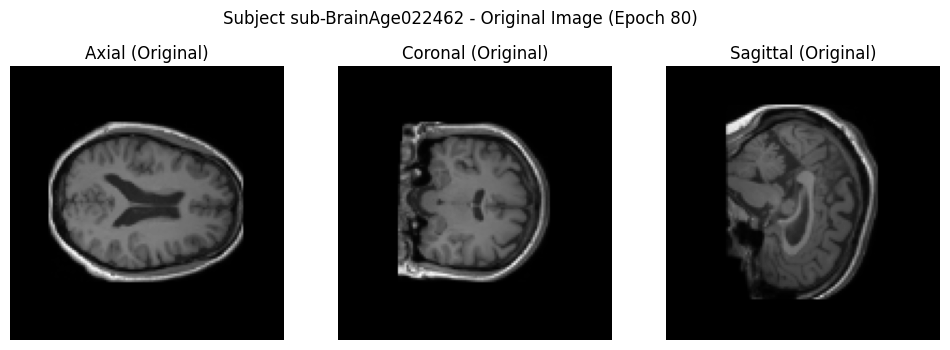

[Epoch 80] Target: Tuổi đích 25, Giới tính đích Nam


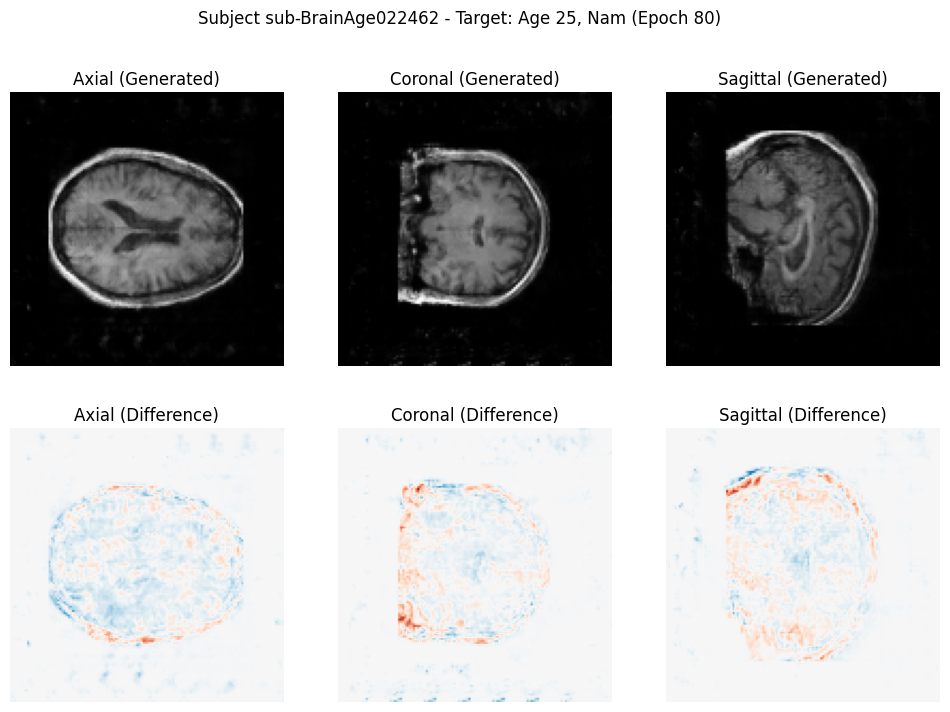

[Epoch 80] Target: Tuổi đích 25, Giới tính đích Nữ


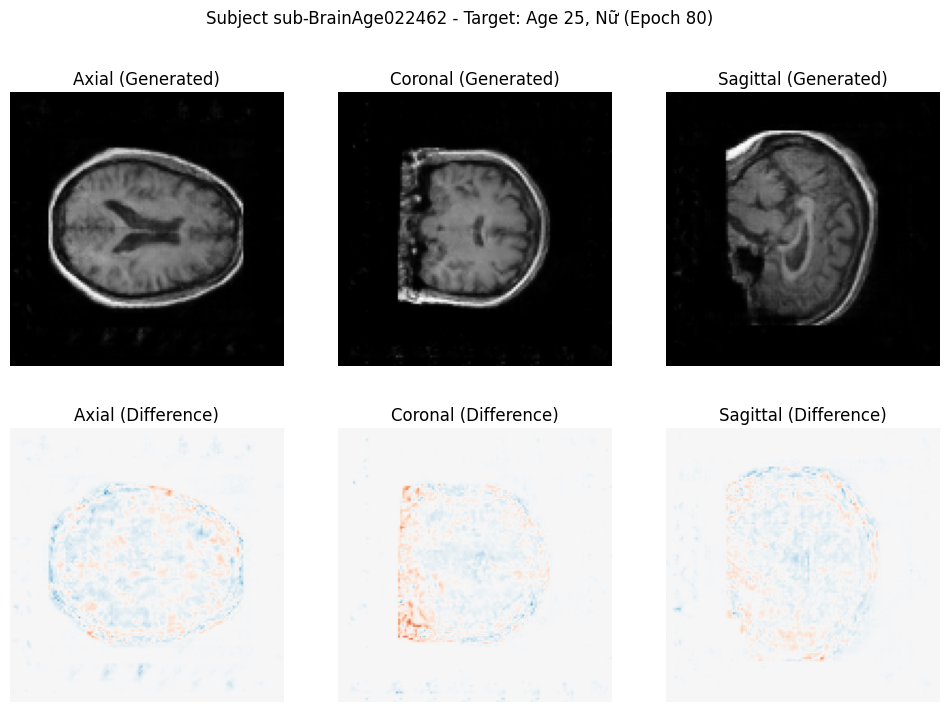

[Epoch 80] Target: Tuổi đích 50, Giới tính đích Nam


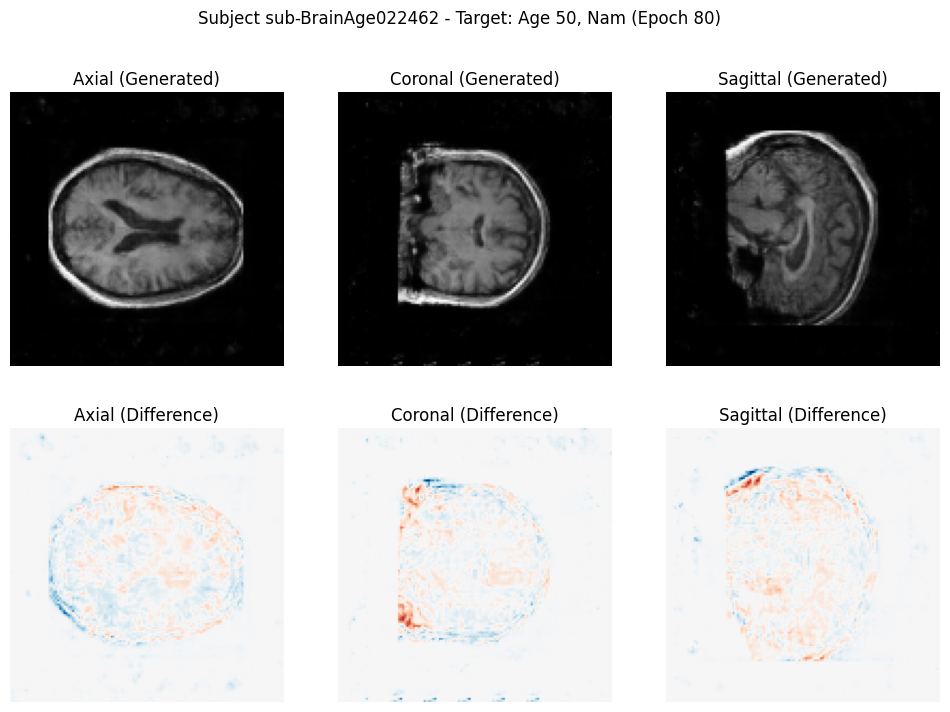

[Epoch 80] Target: Tuổi đích 50, Giới tính đích Nữ


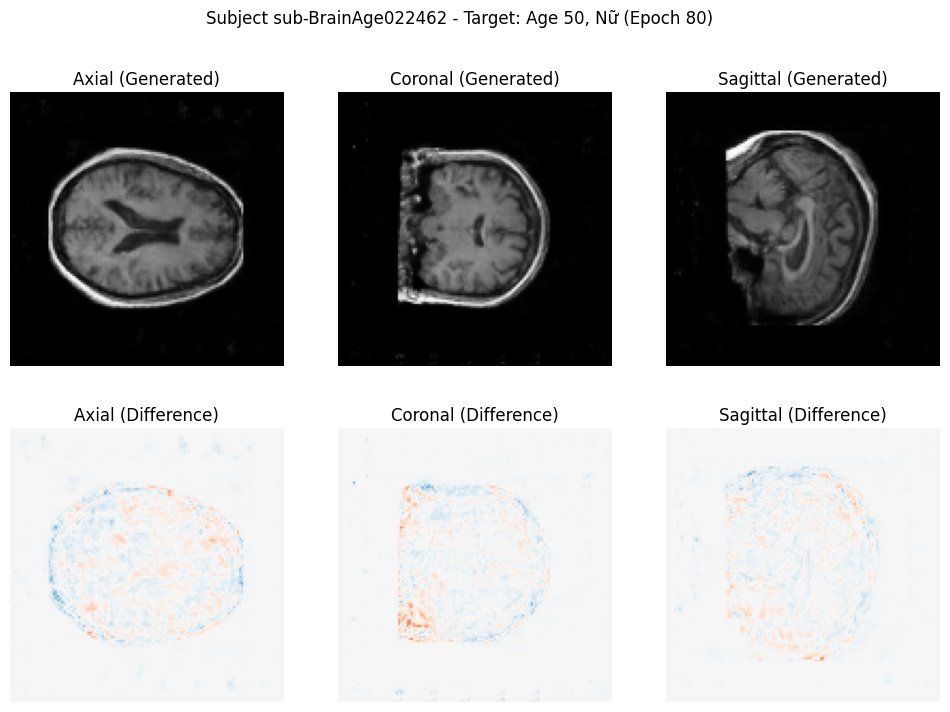


[Epoch 80] Subject: sub-BrainAge019911
Tuổi gốc: 45.2, Giới tính gốc: Nữ


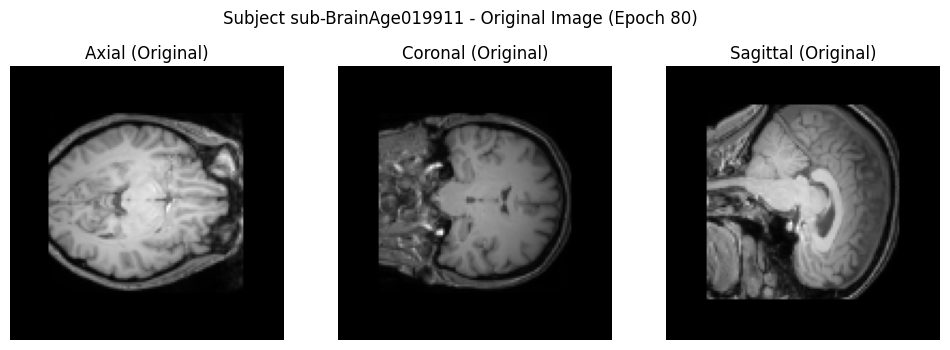

[Epoch 80] Target: Tuổi đích 25, Giới tính đích Nam


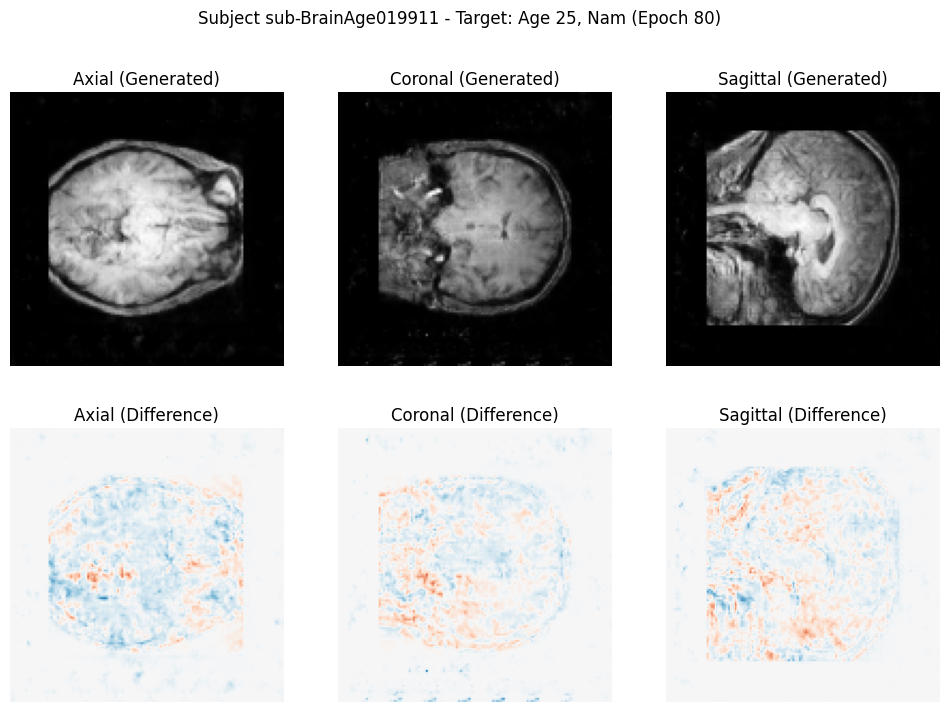

[Epoch 80] Target: Tuổi đích 25, Giới tính đích Nữ


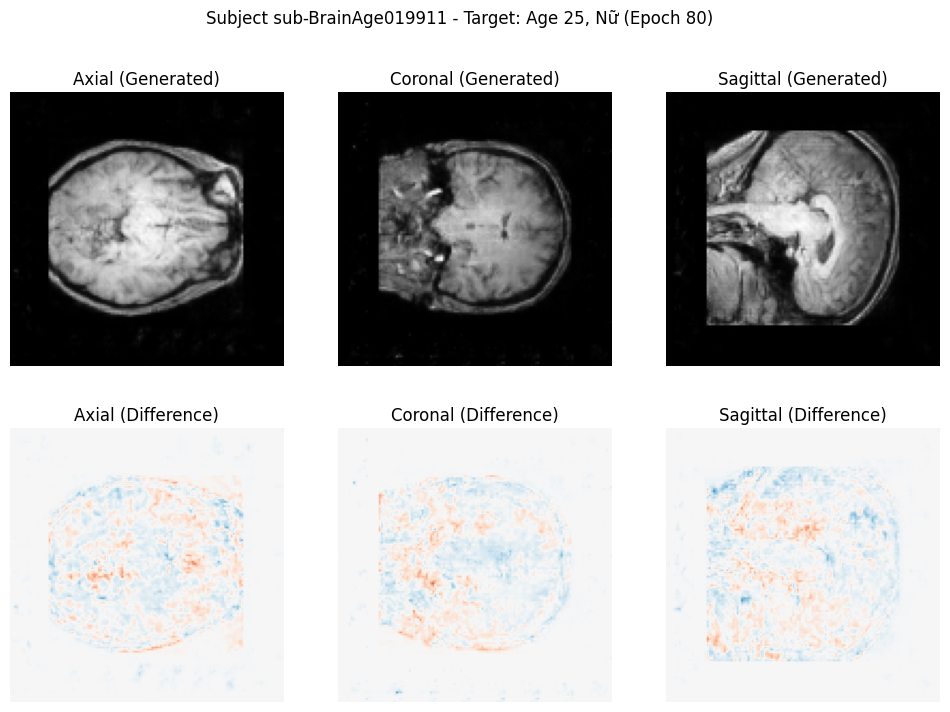

[Epoch 80] Target: Tuổi đích 50, Giới tính đích Nam


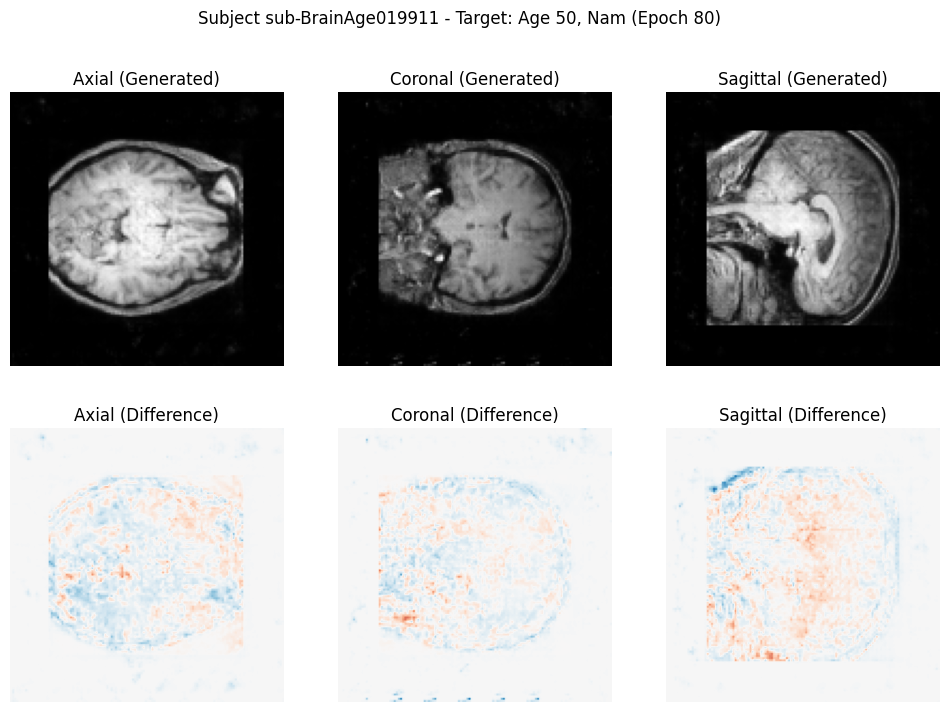

[Epoch 80] Target: Tuổi đích 50, Giới tính đích Nữ


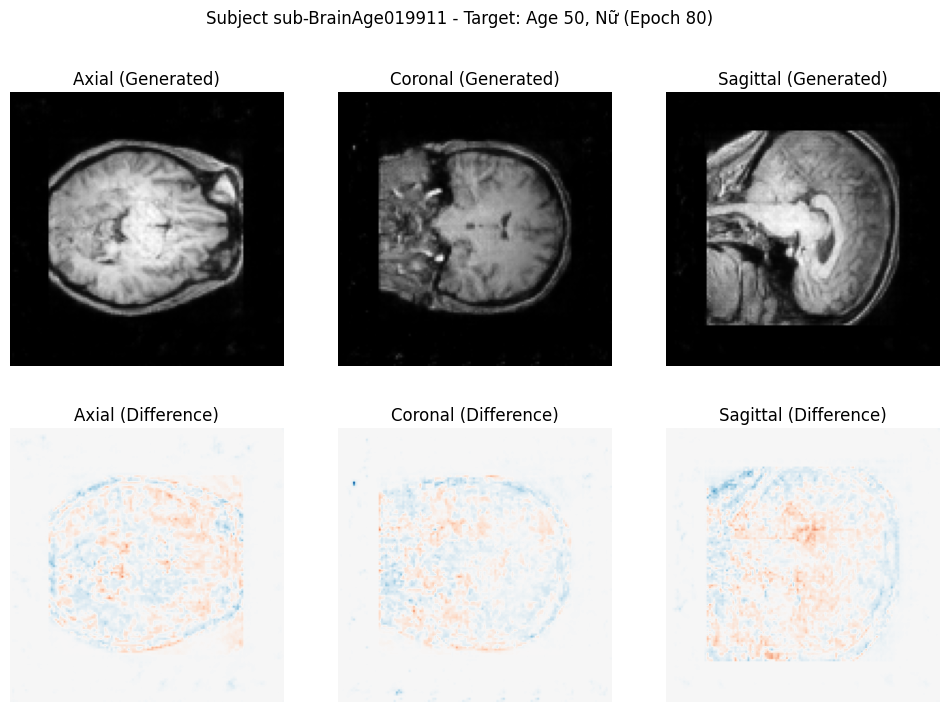

Đã đánh giá và lưu ảnh cho epoch 80


In [ ]:
# Generator với Unet và skip connections
class Generator(nn.Module):
    def __init__(self, condition_dim=4, in_channels=3):
        super(Generator, self).__init__()
        self.condition_dim = condition_dim
        self.condition_layer = nn.Sequential(
            nn.Linear(condition_dim, 128),
            nn.ReLU(),
        )

        # Encoder
        self.enc1 = nn.Conv2d(in_channels + 1, 64, kernel_size=4, stride=2, padding=1)
        self.enc2 = nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1)
        self.enc3 = nn.Conv2d(128, 256, kernel_size=4, stride=2, padding=1)
        self.enc4 = nn.Conv2d(256, 512, kernel_size=4, stride=2, padding=1)

        # Decoder với skip connections
        self.dec4 = nn.ConvTranspose2d(512, 256, kernel_size=4, stride=2, padding=1)
        self.dec3 = nn.ConvTranspose2d(512, 128, kernel_size=4, stride=2, padding=1)
        self.dec2 = nn.ConvTranspose2d(256, 64, kernel_size=4, stride=2, padding=1)
        self.dec1 = nn.ConvTranspose2d(128, 3, kernel_size=4, stride=2, padding=1)

        self.leaky_relu = nn.LeakyReLU(0.2)
        self.relu = nn.ReLU()
        self.tanh = nn.Tanh()

    def forward(self, x, condition):
        batch_size = x.size(0)
        condition = condition[:batch_size]
        condition = self.condition_layer(condition)
        condition = condition.view(batch_size, 1, 128, 1).expand(batch_size, 1, 128, 128)
        x = torch.cat([x, condition], dim=1)

        # Encoder
        e1 = self.leaky_relu(self.enc1(x))
        e2 = self.leaky_relu(self.enc2(e1))
        e3 = self.leaky_relu(self.enc3(e2))
        e4 = self.leaky_relu(self.enc4(e3))

        # Decoder với skip connections
        d4 = self.relu(self.dec4(e4))
        d4 = torch.cat([d4, e3], dim=1)
        d3 = self.relu(self.dec3(d4))
        d3 = torch.cat([d3, e2], dim=1)
        d2 = self.relu(self.dec2(d3))
        d2 = torch.cat([d2, e1], dim=1)
        d1 = self.tanh(self.dec1(d2))

        return d1

# Khởi tạo Generator
G_A_to_B = Generator().to(device)

# Hàm đánh giá và lưu ảnh
def evaluate_and_save_images(model, dataset, subjects, min_age, max_age, epoch, model_path):
    print(f"Đang tải mô hình từ {model_path}...")
    model.load_state_dict(torch.load(model_path, map_location=device))
    model.eval()

    #Thực hiện sinh ảnh ở các độ tuổi và giới tính khác nhau
    test_subjects = random.sample(subjects, 2)
    target_conditions = [(25, 1), (25, 0), (50, 1), (50, 0)]
    
    for subject_id in test_subjects:
        idx = subjects.index(subject_id)
        real, condition = dataset[idx]
        real = real.unsqueeze(0).to(device)
        condition = condition.unsqueeze(0).to(device)
        orig_age = subject_info[subject_id]['age']
        orig_gender = subject_info[subject_id]['gender']
        real_np = real.squeeze(0).cpu().numpy()
        
        print(f"\n[Epoch {epoch+1}] Subject: {subject_id}")
        print(f"Tuổi gốc: {orig_age:.1f}, Giới tính gốc: {'Nam' if orig_gender == 1 else 'Nữ'}")
        
        # Hiển thị và lưu ảnh gốc
        fig, axes = plt.subplots(1, 3, figsize=(12, 4))
        for i, plane in enumerate(['Axial', 'Coronal', 'Sagittal']):
            axes[i].imshow(real_np[i], cmap='gray')
            axes[i].set_title(f"{plane} (Original)")
            axes[i].axis('off')
        plt.suptitle(f"Subject {subject_id} - Original Image (Epoch {epoch+1})")
        plt.show()
        
        for target_age, target_gender in target_conditions:
            target_age_normalized = (target_age - min_age) / (max_age - min_age)
            condition_target = torch.tensor([condition[0, 0].item(), condition[0, 1].item(), target_age_normalized, float(target_gender)]).unsqueeze(0).to(device)
            
            with torch.no_grad():
                counterfactual = model(real, condition_target)
            
            counterfactual_np = counterfactual.squeeze(0).cpu().numpy()
            diff_np = counterfactual_np - real_np  # Tính sự thay đổi
            
            # Hiển thị và lưu ảnh sinh + chênh lệch
            print(f"[Epoch {epoch+1}] Target: Tuổi đích {target_age}, Giới tính đích {'Nam' if target_gender == 1 else 'Nữ'}")
            
            fig, axes = plt.subplots(2, 3, figsize=(12, 8))
            for i, plane in enumerate(['Axial', 'Coronal', 'Sagittal']):
                # Ảnh sinh (hàng trên)
                axes[0, i].imshow(counterfactual_np[i], cmap='gray')
                axes[0, i].set_title(f"{plane} (Generated)")
                axes[0, i].axis('off')
                # Ảnh chênh lệch (hàng dưới)
                axes[1, i].imshow(diff_np[i], cmap='RdBu', vmin=-1, vmax=1)
                axes[1, i].set_title(f"{plane} (Difference)")
                axes[1, i].axis('off')
            plt.suptitle(f"Subject {subject_id} - Target: Age {target_age}, {'Nam' if target_gender == 1 else 'Nữ'} (Epoch {epoch+1})")
            gender_label = 'Male' if target_gender == 1 else 'Female'
            plt.show()
    
    model.train()
    print(f"Đã đánh giá và lưu ảnh cho epoch {epoch+1}")

# Đường dẫn mô hình đã lưu (giả sử trong /kaggle/input/)
model_path_epoch_80 = "/kaggle/input/modelcyclegan/G_A_to_B_epoch_80.pth"

# Đánh giá và lưu ảnh cho epoch 80
evaluate_and_save_images(G_A_to_B, dataset, subjects, min_age, max_age, 79, model_path_epoch_80)
